In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
from tabulate import tabulate

In [4]:
# --- 1. LOAD AND PREPARE DATA ---
# Start with the original cleaned file
df = pd.read_csv("ML_dataset_cleaned_without_one_hot_encoding.csv")

# ✨ --- CRUCIAL NEW STEP: REMOVE THE 'UNKNOWN' CLASS --- ✨
print(f"Original dataset shape: {df.shape}")
df = df[df['Severity'] != 'Unknown']
print(f"Dataset shape after removing 'Unknown' class: {df.shape}\n")

# --- 2. SEPARATE AND ENCODE ---
# Separate features (X) and target (y)
y = df['Severity']
X = df.drop(columns=['Severity', 'User_ID'], errors='ignore')

# Encode the new 3-class target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# One-hot encode the features
X_encoded = pd.get_dummies(X, drop_first=True)


# --- 3. SCALE AND SPLIT ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# --- 4. APPLY SMOTE ---
# SMOTE is still useful as the 3 classes might not be perfectly balanced
print("Class distribution before SMOTE:", pd.Series(y_train).value_counts().sort_index())
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Class distribution after SMOTE:", pd.Series(y_train_resampled).value_counts().sort_index())


# --- 5. TRAIN FINAL XGBOOST MODEL ---
print("\n💪 Training XGBoost model on the filtered, balanced data...")
# The number of classes is now 3
final_model = xgb.XGBClassifier(
    objective='multi:softprob',   # 改这里！
    num_class=len(label_encoder.classes_),
    seed=42
)
final_model.fit(X_train_resampled, y_train_resampled)
print("✅ Training complete.")


# --- 6. EVALUATE THE NEW MODEL ---
print("\n🔍 Evaluating the new 3-class model...")
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)

# --- Calculate Metrics ---
accuracy = accuracy_score(y_test, y_pred)
macro_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
macro_f1 = f1_score(y_test, y_pred, average='macro')

# --- Display Results Table ---
table_data = [
    ["Accuracy", f"{accuracy * 100:.2f} %"],
    ["Macro AUC", f"{macro_auc * 100:.2f} %"],
    ["Macro F1-Score", f"{macro_f1 * 100:.2f} %"]
]
headers = ["XGBoost (3-Class)", ""]
print("\n" + tabulate(table_data, headers=headers, tablefmt="grid") + "\n")

# --- Display Detailed Report ---
print("\n--- Detailed Classification Report (3-Class Model) ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Original dataset shape: (50000, 17)
Dataset shape after removing 'Unknown' class: (24998, 17)

Class distribution before SMOTE: 0    6641
1    6609
2    6748
dtype: int64
Class distribution after SMOTE: 0    6748
1    6748
2    6748
dtype: int64

💪 Training XGBoost model on the filtered, balanced data...
✅ Training complete.

🔍 Evaluating the new 3-class model...

+---------------------+---------+
| XGBoost (3-Class)   |         |
+=====================+=========+
| Accuracy            | 32.56 % |
+---------------------+---------+
| Macro AUC           | 49.59 % |
+---------------------+---------+
| Macro F1-Score      | 32.54 % |
+---------------------+---------+


--- Detailed Classification Report (3-Class Model) ---
              precision    recall  f1-score   support

        High       0.32      0.31      0.31      1660
         Low       0.32      0.32      0.32      1652
      Medium       0.34      0.35      0.34      1688

    accuracy                           0.33      500

In [8]:
# === SHAP for XGBoost: produce table (rows=features, cols=3 classes) ===
import shap, numpy as np, pandas as pd

# 1) 确保训练时用的是 multi:softprob（概率输出）
# final_model = xgb.XGBClassifier(objective='multi:softprob', num_class=3, seed=42)

# 2) 恢复特征名
X_train_df = pd.DataFrame(X_train, columns=X_encoded.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X_encoded.columns)
n_features = X_test_df.shape[1]

# 3) 用 TreeExplainer（多分类返回 "list of arrays"，长度 = n_classes）
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_df)

# 4) 形状诊断（关键！）
print("[Debug] type(shap_values):", type(shap_values))
if isinstance(shap_values, list):
    print("[Debug] #classes from list:", len(shap_values))
    # 每个元素通常是 (n_samples, n_features)
    per_class_importance = []
    for i, sv in enumerate(shap_values):
        sv = np.asarray(sv)
        if sv.ndim != 2:
            raise ValueError(f"Unexpected sv shape for class {i}: {sv.shape}")
        # 识别特征轴
        if sv.shape[1] == n_features:           # (n_samples, n_features)
            imp = np.mean(np.abs(sv), axis=0)   # -> (n_features,)
        elif sv.shape[0] == n_features:         # (n_features, n_samples)
            imp = np.mean(np.abs(sv), axis=1)
        else:
            raise ValueError(f"Cannot find feature axis in {sv.shape} vs n_features={n_features}")
        per_class_importance.append(imp)

    n_classes = len(per_class_importance)
    shap_xgb = pd.DataFrame(
        np.vstack(per_class_importance).T,      # (n_features, n_classes)
        index=X_test_df.columns,
        columns=[f"class_{i}" for i in range(n_classes)]
    )

else:
    # 有些版本/接口可能返回 Explanation，values 形状为 (N, F, C) 或 (N, C, F)
    vals = np.asarray(shap_values)  # 或 explainer(X_test_df).values
    print("[Debug] shap_values array shape:", vals.shape)
    if vals.ndim != 3:
        raise ValueError(f"Unexpected SHAP values ndim: {vals.ndim}, shape={vals.shape}")

    # 规范到 (C, N, F)
    N, A, B = vals.shape
    if A == n_features:              # (N, F, C)
        vals = np.transpose(vals, (2, 0, 1))
    elif B == n_features:            # (N, C, F)
        vals = np.transpose(vals, (1, 0, 2))
    else:
        raise ValueError(f"Cannot align features: SHAP shape={vals.shape}, n_features={n_features}")

    n_classes = vals.shape[0]
    per_class_importance = [np.mean(np.abs(vals[c]), axis=0) for c in range(n_classes)]
    shap_xgb = pd.DataFrame(
        np.vstack(per_class_importance).T,
        index=X_test_df.columns,
        columns=[f"class_{i}" for i in range(n_classes)]
    )

# 5) 列名映射为真实类名（若可用）
if hasattr(label_encoder, "classes_") and len(label_encoder.classes_) == shap_xgb.shape[1]:
    shap_xgb = shap_xgb.rename(columns={f"class_{i}": str(label_encoder.classes_[i]) for i in range(shap_xgb.shape[1])})
else:
    # 如果 label_encoder 不可用或数量不匹配，可用固定映射
    if shap_xgb.shape[1] == 3:
        shap_xgb = shap_xgb.rename(columns={"class_0": "Low", "class_1": "Medium", "class_2": "High"})

# 6) 按整体重要性排序
shap_xgb["overall_mean_abs"] = shap_xgb.mean(axis=1)
shap_xgb = shap_xgb.sort_values("overall_mean_abs", ascending=False).drop(columns=["overall_mean_abs"])

print("\n--- SHAP importance table (XGBoost) ---")
print(shap_xgb.round(6))

[Debug] type(shap_values): <class 'numpy.ndarray'>
[Debug] shap_values array shape: (5000, 33, 3)

--- SHAP importance table (XGBoost) ---
                                         High       Low    Medium
Work_Hours                           0.084625  0.085722  0.088370
Social_Media_Usage                   0.081638  0.088728  0.075460
Age                                  0.083947  0.079459  0.081344
Sleep_Hours                          0.082387  0.079009  0.082548
Physical_Activity_Hours              0.057417  0.054174  0.053721
Alcohol_Consumption_Social Drinker   0.036489  0.012944  0.023780
Diet_Quality_Healthy                 0.017138  0.030746  0.019778
Consultation_History_Yes             0.016868  0.026126  0.023754
Diet_Quality_Unhealthy               0.020515  0.024545  0.019570
Stress_Level_Low                     0.018964  0.019664  0.020213
Mental_Health_Condition_Yes          0.019694  0.020552  0.018307
Medication_Usage_Yes                 0.013659  0.022850  0.021603
Smo

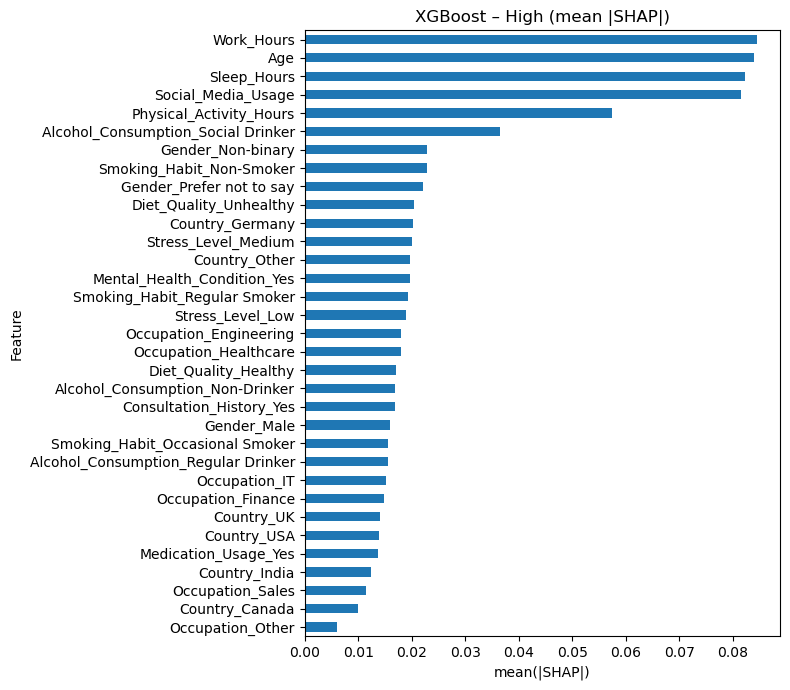

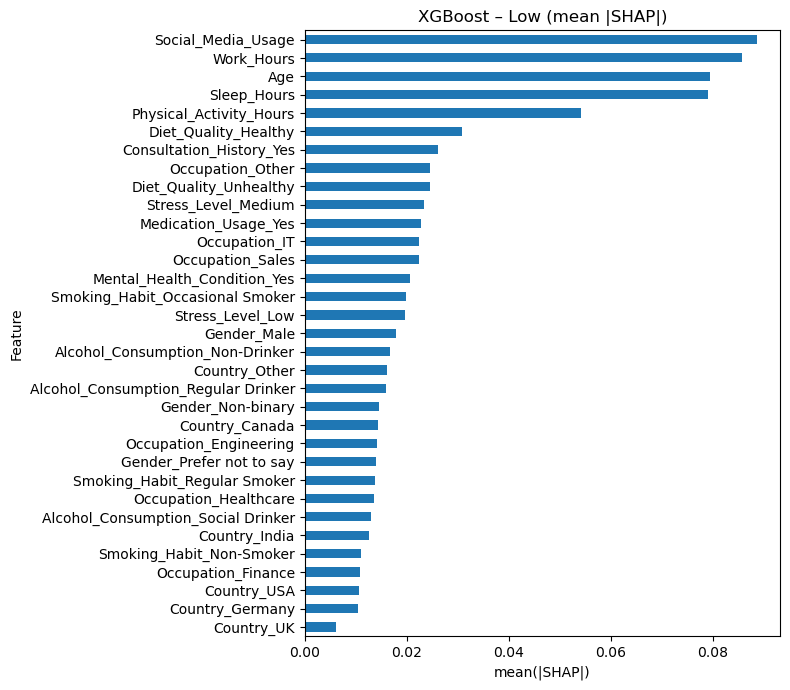

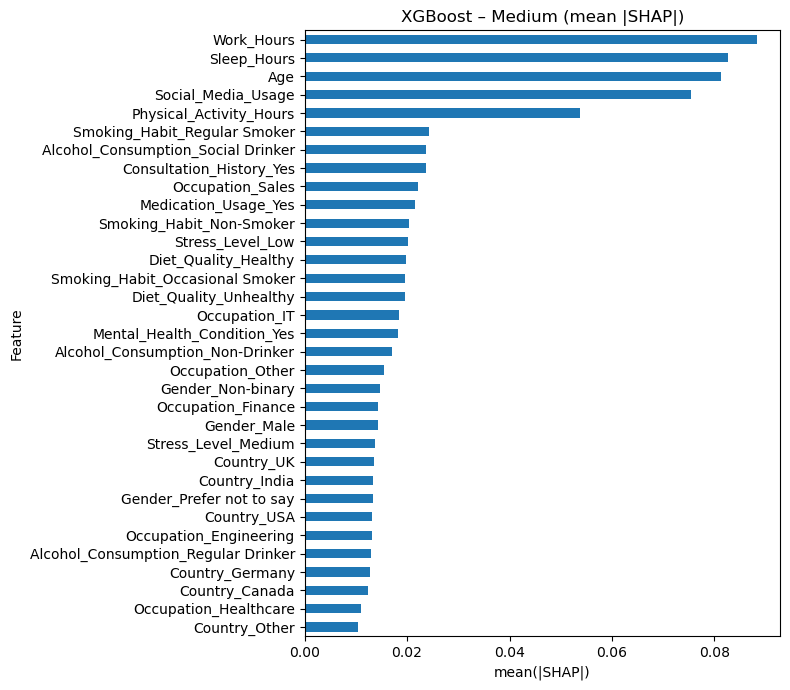

In [9]:
# 假设你已经有 shap_xgb: 行=特征, 列=3类（如 'Low','Medium','High'）
import matplotlib.pyplot as plt

for col in shap_xgb.columns:
    ax = shap_xgb[col].sort_values(ascending=True).plot.barh(figsize=(8, 7))
    ax.set_xlabel("mean(|SHAP|)")
    ax.set_ylabel("Feature")
    ax.set_title(f"XGBoost – {col} (mean |SHAP|)")
    plt.tight_layout()
    plt.savefig(f"xgb_shap_bar_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()